In [1]:
import pandas as pd
import numpy as np

In [2]:
import chardet

with open("cleaned_earthquakes1.csv", 'rb') as f:
    result = chardet.detect(f.read(100000))
print(result)

{'encoding': 'utf-8', 'confidence': 0.99, 'language': ''}


In [3]:
import chardet

with open("cleaned_seismic1.csv", 'rb') as f:
    result = chardet.detect(f.read(100000))
print(result)

{'encoding': 'ISO-8859-1', 'confidence': 0.73, 'language': ''}



================ Random Forest Classifier ================
10-Fold CV Accuracy: 0.893 ± 0.001
ROC-AUC (macro): 0.619

Confusion Matrix:
 [[    1   311    19     0]
 [   25 43174   800     1]
 [   15  3956   281     0]
 [    0    38     2     0]]

Classification Report:
               precision    recall  f1-score   support

        High      0.024     0.003     0.005       331
         Low      0.909     0.981     0.944     44000
    Moderate      0.255     0.066     0.105      4252
   Very High      0.000     0.000     0.000        40

    accuracy                          0.894     48623
   macro avg      0.297     0.263     0.264     48623
weighted avg      0.845     0.894     0.863     48623



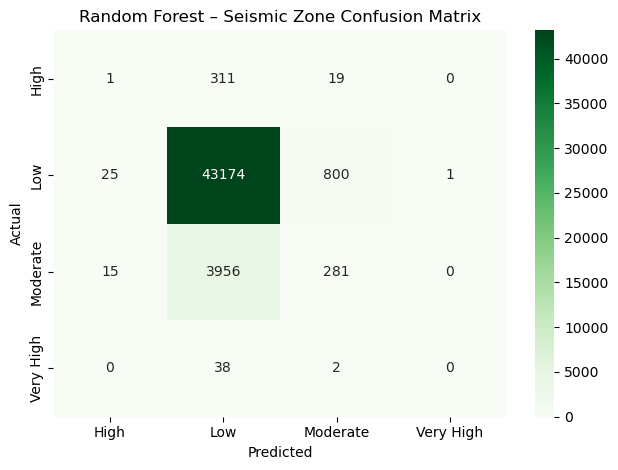

In [4]:
# === 1. Import Libraries ===
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# === 2. Load the Earthquake Dataset ===
eq_df = pd.read_csv("cleaned_earthquakes1.csv", encoding='utf-8')

# === 3. Assign Seismic Zones Based on Magnitude ===
def assign_zone(mag):
    if mag < 5.0:
        return "Low"
    elif 5.0 <= mag < 6.0:
        return "Moderate"
    elif 6.0 <= mag < 7.0:
        return "High"
    else:
        return "Very High"

eq_df['seismic_zone'] = eq_df['mag'].apply(assign_zone)

# === 4. Encode Labels ===
le_zone = LabelEncoder()
eq_df['zone_label'] = le_zone.fit_transform(eq_df['seismic_zone'])

# === 5. Define Features and Target ===
X = eq_df[['latitude', 'longitude']]
y = eq_df['zone_label']

# === 6. Split and Train Random Forest Model ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(n_estimators=200, random_state=42)

# === 7. Evaluate Model (10-Fold CV + Metrics) ===
print("\n================ Random Forest Classifier ================")
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
print(f"10-Fold CV Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# Train model on full training data
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Try ROC-AUC (multi-class)
try:
    y_prob = model.predict_proba(X_test)
    auc = roc_auc_score(y_test, y_prob, multi_class='ovr')
    print(f"ROC-AUC (macro): {auc:.3f}")
except:
    print("ROC-AUC not available (no predict_proba).")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# Classification Report
report = classification_report(y_test, y_pred, target_names=le_zone.classes_, digits=3)
print("\nClassification Report:\n", report)

# === 8. Visualize Confusion Matrix ===
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le_zone.classes_, yticklabels=le_zone.classes_)
plt.title('Random Forest – Seismic Zone Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [5]:
# === 9. Save Model ===
joblib.dump(model, "seismic_zone_model.pkl")
joblib.dump(le_zone, "zone_label_encoder.pkl")

print("✅ Model and label encoder saved successfully!")

✅ Model and label encoder saved successfully!


In [10]:
# === Save Smaller Model ===
joblib.dump(model, "seismic_zone_model.pkl", compress=3)
joblib.dump(le_zone, "zone_label_encoder.pkl", compress=3)

print("✅ Re-saved lightweight seismic zone model")

✅ Re-saved lightweight seismic zone model


In [9]:
from sklearn.ensemble import RandomForestClassifier
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# === Load dataset ===
eq_df = pd.read_csv("cleaned_earthquakes1.csv")

# === Assign Seismic Zones ===
def assign_zone(mag):
    if mag < 5.0:
        return "Low"
    elif 5.0 <= mag < 6.0:
        return "Moderate"
    elif 6.0 <= mag < 7.0:
        return "High"
    else:
        return "Very High"

eq_df['seismic_zone'] = eq_df['mag'].apply(assign_zone)

le_zone = LabelEncoder()
eq_df['zone_label'] = le_zone.fit_transform(eq_df['seismic_zone'])

X = eq_df[['latitude', 'longitude']]
y = eq_df['zone_label']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# ✅ Train with fewer trees and depth limits to reduce size
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

# === Save Smaller Model ===
joblib.dump(model, "seismic_zone_model2.pkl", compress=3)
joblib.dump(le_zone, "zone_label_encoder2.pkl", compress=3)

print("✅ Re-saved lightweight seismic zone model")


✅ Re-saved lightweight seismic zone model


In [6]:
# =====================================================
# End-to-End: Train tuned RF regressors (Y2, Y3) + RF classifier (Y4)
# then provide an interactive prediction function predict_all(...)
# =====================================================

import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings("ignore")

# sklearn imports
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, confusion_matrix, classification_report, roc_auc_score
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from xgboost import XGBRegressor
from imblearn.over_sampling import SMOTE

# ----------------------------
# --- 0. Config / filenames
# ----------------------------
SEISMIC_FILE = "cleaned_seismic1.csv"
EARTHQUAKE_ZONE_MODEL_FILE = "seismic_zone_model.pkl"     # produced from Stage 1
EARTHQUAKE_ZONE_LE_FILE = "zone_label_encoder.pkl"

RF_Y2_FILE = "best_rf_y2.pkl"
RF_Y3_FILE = "best_rf_y3.pkl"
SCALER_FILE = "regression_scaler.pkl"
REG_FEATURES_FILE = "reg_features.pkl"      # list of columns used for regressors (after get_dummies)
CLASS_FEATURES_FILE = "class_features.pkl"  # list of columns used for classifier (after get_dummies)
RF_Y4_FILE = "best_rf_y4.pkl"
Y4_LE_FILE = "collapse_label_encoder.pkl"

# ----------------------------
# --- 1. Load seismic dataset
# ----------------------------
seismic_df = pd.read_csv(SEISMIC_FILE, encoding='ISO-8859-1')

# Ensure required target columns exist (these were computed earlier by your formula)
# Y2: Predicted Damage Index (01 Scale)
# Y3: Predicted Collapse Probability (%)
assert 'Predicted Damage Index (01 Scale)' in seismic_df.columns, "Missing Predicted Damage Index (01 Scale)"
assert 'Predicted Collapse Probability (%)' in seismic_df.columns, "Missing Predicted Collapse Probability (%)"

# ----------------------------
# --- 2. Prepare features (common set)
# ----------------------------
feature_cols = [
    'Seismic Zone', 'PGA (m/s²)', 'PGV (m/s)', 'PGD (m)',
    'Spectral Acceleration (g)', 'Soil Type', 'Site Amplification Factor',
    'Historical Earthquake Magnitude (Mw)', 'Fault Distance (km)',
    'Seismic Wave Frequency (Hz)', 'Building Height (m)', 'Number of Stories',
    'Structural Material', 'Foundation Type', 'Natural Frequency (Hz)',
    'Damping Ratio (%)', 'Mass of Structure (kg)', 'Axial Stiffness (kN/m)',
    'Bending Stiffness (kN·m²)', 'Lateral Load Resisting System'
]

# keep only rows with no missing values in features + targets
cols_needed = feature_cols + ['Predicted Damage Index (01 Scale)', 'Predicted Collapse Probability (%)']
df = seismic_df[cols_needed].dropna().copy()
print(f"Using {len(df)} rows (after dropping NA).")

# X and targets
X_raw = df[feature_cols]
y2 = df['Predicted Damage Index (01 Scale)']   # range 0-1
y3 = df['Predicted Collapse Probability (%)']  # range 0-100

# ----------------------------
# --- 3. One-hot encode categorical features (same transform used for regressors & classifier)
# ----------------------------
X_encoded = pd.get_dummies(X_raw, drop_first=True)

# record feature list for regressors/classifier (we'll use same encoding for both here)
reg_feature_columns = X_encoded.columns.tolist()
joblib.dump(reg_feature_columns, REG_FEATURES_FILE)

# ----------------------------
# --- 4. Train/Test split & scaler for regressors
# ----------------------------
X_train, X_test, y2_train, y2_test = train_test_split(X_encoded, y2, test_size=0.2, random_state=42)
_, _, y3_train, y3_test = train_test_split(X_encoded, y3, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
joblib.dump(scaler, SCALER_FILE)

# ----------------------------
# --- 5. GridSearch for RandomForestRegressor (Y2)
# ----------------------------
print("\n--- GridSearch RF Regressor for Y2 (Damage Index) ---")
rf_r_param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
rf_r = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_r_grid = GridSearchCV(rf_r, rf_r_param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=1)
rf_r_grid.fit(X_train_scaled, y2_train)
best_rf_y2 = rf_r_grid.best_estimator_
print("Best params (Y2):", rf_r_grid.best_params_)
print("Best CV R² (Y2):", rf_r_grid.best_score_)

# Evaluate on test
y2_pred = best_rf_y2.predict(X_test_scaled)
print("Y2 test R²:", r2_score(y2_test, y2_pred))
print("Y2 test RMSE:", np.sqrt(mean_squared_error(y2_test, y2_pred)))
print("Y2 test MAE:", mean_absolute_error(y2_test, y2_pred))

# save
joblib.dump(best_rf_y2, RF_Y2_FILE)

# ----------------------------
# --- 6. GridSearch for RandomForestRegressor (Y3) ---
# ----------------------------
# Scale Y3 to 0-1 for stability during training, then rescale back when predicting.
y3_train_scaled = y3_train / 100.0
y3_test_scaled = y3_test / 100.0

print("\n--- GridSearch RF Regressor for Y3 (Collapse Probability scaled 0-1) ---")
rf_r2 = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_r_grid2 = GridSearchCV(rf_r2, rf_r_param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=1)
rf_r_grid2.fit(X_train_scaled, y3_train_scaled)
best_rf_y3 = rf_r_grid2.best_estimator_
print("Best params (Y3):", rf_r_grid2.best_params_)
print("Best CV R² (Y3):", rf_r_grid2.best_score_)

# Evaluate on test (remember to rescale predictions back to 0-100)
y3_pred_scaled = best_rf_y3.predict(X_test_scaled)
y3_pred = y3_pred_scaled * 100.0
print("Y3 test R²:", r2_score(y3_test, y3_pred))
print("Y3 test RMSE:", np.sqrt(mean_squared_error(y3_test, y3_pred)))
print("Y3 test MAE:", mean_absolute_error(y3_test, y3_pred))

# save
joblib.dump(best_rf_y3, RF_Y3_FILE)

# ----------------------------
# --- 7. Train RandomForestClassifier for Y4 (using collapse_risk derived from y3) ---
# ----------------------------
# Build Y4 labels from y3 (same thresholds you used before)
def classify_risk_val(prob):
    if prob < 30:
        return 'Low'
    elif 30 <= prob < 70:
        return 'Medium'
    else:
        return 'High'

y4 = y3.apply(classify_risk_val)

# encode target
le_y4 = LabelEncoder()
y4_encoded = le_y4.fit_transform(y4)
joblib.dump(le_y4, Y4_LE_FILE)

# For classifier, we will use the same X_encoded features (no scaling required for RF).
# Balance classes with SMOTE (on train only)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_encoded, y4_encoded, test_size=0.2, random_state=42, stratify=y4_encoded)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_clf, y_train_clf)
print("\nAfter SMOTE balancing for Y4:", np.bincount(y_train_res))

# Train baseline RandomForestClassifier (we keep tuning small to save time)
clf = RandomForestClassifier(random_state=42, n_jobs=-1)
clf_param_grid = {
    'n_estimators': [200, 500],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 2]
}
clf_grid = GridSearchCV(clf, clf_param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
clf_grid.fit(X_train_res, y_train_res)
best_rf_y4 = clf_grid.best_estimator_
print("Best params (Y4 classifier):", clf_grid.best_params_)
print("Best CV acc (Y4):", clf_grid.best_score_)

# Evaluate on test set
y4_pred = best_rf_y4.predict(X_test_clf)
print("\nY4 Classification Report (test):\n", classification_report(y_test_clf, y4_pred, target_names=le_y4.classes_))
cm = confusion_matrix(y_test_clf, y4_pred)
print("Confusion matrix:\n", cm)

# save classifier and feature list
joblib.dump(best_rf_y4, RF_Y4_FILE)
joblib.dump(list(X_encoded.columns), CLASS_FEATURES_FILE)

# ----------------------------
# --- 8. Save regression feature list too (already saved reg_feature_columns earlier) ---
joblib.dump(reg_feature_columns, REG_FEATURES_FILE)

print("\n✅ All models trained and saved:")
print(" -", RF_Y2_FILE)
print(" -", RF_Y3_FILE)
print(" -", RF_Y4_FILE)
print(" -", SCALER_FILE)
print(" -", REG_FEATURES_FILE)
print(" -", CLASS_FEATURES_FILE)
print(" -", Y4_LE_FILE)

Using 1000 rows (after dropping NA).

--- GridSearch RF Regressor for Y2 (Damage Index) ---
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best params (Y2): {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best CV R² (Y2): -0.058272175400756986
Y2 test R²: -0.038478680058847914
Y2 test RMSE: 0.29044372455957956
Y2 test MAE: 0.24971385941806762

--- GridSearch RF Regressor for Y3 (Collapse Probability scaled 0-1) ---
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best params (Y3): {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best CV R² (Y3): -0.05860272564910307
Y3 test R²: -0.04122545282798584
Y3 test RMSE: 29.082758226928494
Y3 test MAE: 24.998028158101825

After SMOTE balancing for Y4: [312 312 312]
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best params (Y4 classifier): {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 500}
Best CV acc (Y4): 0.45726495726

In [7]:
# ----------------------------
# --- 9. Prediction helper function (interactive or programmatic)
# ----------------------------
# This function loads the saved models (zone predictor + regressors + classifier),
# constructs the same one-hot features, scales for regressors, then returns Y2, Y3, Y4.
from sklearn.base import BaseEstimator

def predict_all(lat, lon, user_inputs_dict):
    """
    Inputs:
      - lat, lon: floats for location (used to predict Seismic Zone via saved stage-1 model)
      - user_inputs_dict: dictionary with keys for all structural inputs, e.g.:
          {
            'Soil Type': 'Clay',
            'Structural Material': 'Reinforced Concrete',
            'Foundation Type': 'Shallow',
            'Lateral Load Resisting System': 'Infilled Frame',
            'PGA (m/s²)': 0.12,
            'PGV (m/s)': 0.03,
            ...
          }
    Returns:
      dict with keys: 'Seismic Zone', 'Damage Index (Y2)', 'Collapse Probability (%) (Y3)', 'Collapse Risk (Y4_classifier)'
    """
    # --- load models & artifacts
    zone_model = joblib.load(EARTHQUAKE_ZONE_MODEL_FILE)
    le_zone_local = joblib.load(EARTHQUAKE_ZONE_LE_FILE)
    rf_y2 = joblib.load(RF_Y2_FILE)
    rf_y3 = joblib.load(RF_Y3_FILE)
    rf_y4 = joblib.load(RF_Y4_FILE)
    le_y4_local = joblib.load(Y4_LE_FILE)
    scaler_local = joblib.load(SCALER_FILE)
    reg_cols = joblib.load(REG_FEATURES_FILE)
    class_cols = joblib.load(CLASS_FEATURES_FILE)

    # --- 1. Predict seismic zone from lat/lon using stage-1 model
    zone_label = zone_model.predict([[lat, lon]])[0]
    seismic_zone = le_zone_local.inverse_transform([zone_label])[0]

    # --- 2. Build a single-row DataFrame with all features required
    # Start with defaults: numeric fields = 0, categorical fields = placeholder
    row = {}
    # populate features expected (feature_cols)
    for col in feature_cols:
        row[col] = np.nan

    # fill provided user inputs
    for k, v in user_inputs_dict.items():
        if k in row:
            row[k] = v

    # ensure seismic zone set
    row['Seismic Zone'] = seismic_zone

    # Convert to DataFrame
    row_df = pd.DataFrame([row])

    # For any missing numeric inputs, set to 0. (You might want to request them in GUI.)
    for c in row_df.columns:
        if row_df[c].isnull().all():
            # detect numeric-like columns by name (heuristic)
            if any(x in c for x in ['PGA', 'PGV', 'PGD', 'Spectral', 'Site', 'Historical', 'Fault', 'Frequency', 'Height', 'Number', 'Natural', 'Damping', 'Mass', 'Axial', 'Bending']):
                row_df[c] = 0.0
            else:
                # for categorical ones, if left blank, set to a valid category that will map to zeros after get_dummies
                row_df[c] = 'Unknown'

    # One-hot encode the row the same way as training
    row_encoded = pd.get_dummies(row_df, drop_first=True)

    # For regressors: align columns to training reg_feature_columns
    X_reg = pd.DataFrame(columns=reg_cols)
    for c in reg_cols:
        X_reg.loc[0, c] = row_encoded.get(c, 0)

    X_reg = X_reg.fillna(0)

    # Scale for regressors
    X_reg_scaled = scaler_local.transform(X_reg)

    # Predict Y2 and Y3
    y2_pred = rf_y2.predict(X_reg_scaled)[0]
    y3_pred_scaled = rf_y3.predict(X_reg_scaled)[0]   # note: y3 regressor trained on scaled 0-1
    # if best_rf_y3 was trained on scaled target (we trained on y3/100), we must rescale:
    if y3_pred_scaled <= 2:   # heuristic: if <=2 then it's likely scaled (0-1); otherwise user data weird
        y3_pred = float(y3_pred_scaled * 100.0)
    else:
        y3_pred = float(y3_pred_scaled)

    # -----------------
    # For classifier (Y4): build classifier features
    X_cls = pd.DataFrame(columns=class_cols)
    for c in class_cols:
        X_cls.loc[0, c] = row_encoded.get(c, 0)
    X_cls = X_cls.fillna(0)

    # Predict Y4 (ml classifier)
    y4_pred_encoded = rf_y4.predict(X_cls)[0]
    y4_pred_label = le_y4_local.inverse_transform([y4_pred_encoded])[0]

    # Also compute rule-based Y4 from y3_pred if you want to compare
    if y3_pred < 30:
        y4_rule = 'Low'
    elif y3_pred < 70:
        y4_rule = 'Medium'
    else:
        y4_rule = 'High'

    # Build outputs
    out = {
        'Seismic Zone (predicted)': seismic_zone,
        'Damage Index (Y2, ML)': float(np.round(y2_pred, 4)),
        'Collapse Probability (%) (Y3, ML)': float(np.round(y3_pred, 3)),
        'Collapse Risk (Y4, ML classifier)': y4_pred_label,
        'Collapse Risk (Y4, rule from Y3)': y4_rule
    }
    return out